In [19]:
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import njit
import scipy

In [20]:
def energy(s, J, h):
    # s is a flat 1D array of spins
    # J is (n, n) matrix
    # h is (n) vector
    return -0.5 * s @ J @ s - h @ s

def make_2d_ising(N,J_scalar,h_scalar):
    # N is the size of the 2D lattice
    # J_scalar is the coupling constant
    # h_scalar is the external field
    
    J = np.zeros((N*N, N*N))
    
    for x in range(N):
        for y in range(N):
            i = x * N + y
            
            # Nearest neighbors with periodic boundary conditions
            right = x * N + (y + 1) % N
            down = ((x + 1) % N) * N + y
            
            J[i, right] = J_scalar
            J[right, i] = J_scalar
            J[i, down] = J_scalar
            J[down, i] = J_scalar
            
    h = np.full(N*N, h_scalar)
    
    return J, h

@njit
def sweep_once(s, J, h, T, E):
    n=len(s)
    for _ in range(n):
        i = np.random.randint(n)
        
        dE = 2 * s[i] * (J[i] @s + h[i])        

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[i] *= -1
            E += dE

    return E

def sim_annealing(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy()


In [23]:
J, h = make_2d_ising(N=20, J_scalar=1.0, h_scalar=0.0)

temps, energies, spin = sim_annealing(
    J, 
    h, 
    T_start=5.0, 
    T_end=0.1, 
    alpha=0.9, 
    sweeps_per_T=1000
)

print("Final energy:", energies[-1])


Final energy: -800.0


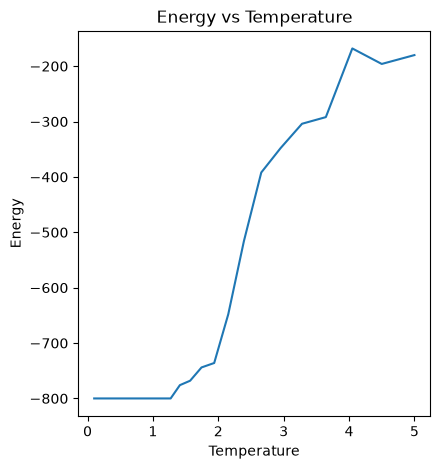

In [24]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(temps, energies)
plt.xlabel('Temperature')
plt.ylabel('Energy')
plt.title('Energy vs Temperature')
plt.show()